# Recommendation Systems from First Principles

## A detailed, self-contained Jupyter notebook

This notebook builds a complete recommendation-system learning example using:

- **50 users**
- **100 items**
- A deliberately **sparse ratings matrix**
- Popularity-based recommendations
- User–user collaborative filtering
- Item–item collaborative filtering
- Content-based fallback for cold start
- Matrix factorization using stochastic gradient descent
- A small market-basket-analysis appendix

The notebook is designed for learners who are new to recommendation systems.  
Every major calculation is implemented directly with NumPy and pandas so that the mathematics remains visible.

---

## Learning goals

By the end, you should understand:

1. How a user–item matrix is created.
2. Why most recommendation matrices contain many missing values.
3. How cosine similarity measures user or item similarity.
4. How user–user collaborative filtering makes predictions.
5. How item–item collaborative filtering makes predictions.
6. How matrix factorization decomposes a large matrix into two smaller matrices.
7. Why cold start happens and how hybrid fallbacks help.
8. How offline recommendation quality can be evaluated.

## 1. Imports and reproducibility

The notebook uses only common Python libraries:

- `numpy` for numerical calculations
- `pandas` for tables
- `matplotlib` for simple visualizations

No external dataset or internet connection is required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 3)

## 2. Create users, items, and item metadata

We create:

- 50 users named `U01` to `U50`
- 100 items named `I001` to `I100`
- 8 simple item categories

The categories are useful later when we discuss cold start and content-based recommendations.

In [2]:
N_USERS = 50
N_ITEMS = 100
N_TRUE_FACTORS = 5

user_ids = [f"U{i:02d}" for i in range(1, N_USERS + 1)]
item_ids = [f"I{i:03d}" for i in range(1, N_ITEMS + 1)]

categories = [
    "Action",
    "Comedy",
    "Drama",
    "Documentary",
    "Food",
    "Technology",
    "Travel",
    "Sports",
]

item_metadata = pd.DataFrame({
    "item_id": item_ids,
    "category": rng.choice(categories, size=N_ITEMS),
    "price_band": rng.choice(
        ["Low", "Medium", "High"],
        size=N_ITEMS,
        p=[0.35, 0.45, 0.20],
    ),
    "is_new_item": False,
})

item_metadata.head(10)

,item_id,category,price_band,is_new_item
0,I001,Action,Low,False
1,I002,Travel,Low,False
2,I003,Technology,Medium,False
3,I004,Documentary,Medium,False
4,I005,Documentary,Medium,False
5,I006,Travel,Medium,False
6,I007,Action,Medium,False
7,I008,Technology,Medium,False
8,I009,Comedy,Low,False
9,I010,Action,Low,False


## 3. Generate realistic hidden preferences

Real recommendation systems observe ratings or interactions, but they do not directly observe a user's hidden taste.

For this synthetic example, we secretly generate:

- A small latent-preference vector for every user
- A small latent-property vector for every item
- User bias: some users rate everything more generously
- Item bias: some items are generally more popular
- Random noise

The full hidden score is:

\[
r_{ui}
=
3
+
b_u
+
b_i
+
\frac{p_u \cdot q_i}{\sqrt{k}}
+
\epsilon
\]

where:

- \(p_u\) is the hidden vector for user \(u\)
- \(q_i\) is the hidden vector for item \(i\)
- \(b_u\) is a user bias
- \(b_i\) is an item bias
- \(k\) is the number of latent dimensions

This complete matrix exists only to generate the toy data.  
Later, the algorithms will see only a small fraction of it.

In [3]:
true_user_factors = rng.normal(0, 0.9, size=(N_USERS, N_TRUE_FACTORS))
true_item_factors = rng.normal(0, 0.9, size=(N_ITEMS, N_TRUE_FACTORS))

true_user_bias = rng.normal(0, 0.25, size=N_USERS)
true_item_bias = rng.normal(0, 0.35, size=N_ITEMS)
noise = rng.normal(0, 0.20, size=(N_USERS, N_ITEMS))

full_hidden_scores = (
    3.0
    + true_user_bias[:, None]
    + true_item_bias[None, :]
    + (true_user_factors @ true_item_factors.T) / np.sqrt(N_TRUE_FACTORS)
    + noise
)

full_hidden_scores = np.clip(full_hidden_scores, 1.0, 5.0)
full_hidden_scores = np.round(full_hidden_scores * 2) / 2

full_hidden_matrix = pd.DataFrame(
    full_hidden_scores,
    index=user_ids,
    columns=item_ids,
)

full_hidden_matrix.iloc[:8, :12]

,I001,I002,I003,I004,I005,I006,I007,I008,I009,I010,I011,I012
U01,2.5,1.5,3.0,2.5,4.0,1.5,2.0,4.0,2.5,4.5,2.5,4.5
U02,3.0,1.5,1.0,3.5,2.5,3.0,2.0,2.5,2.5,2.5,2.5,2.0
U03,4.0,2.0,4.0,4.0,2.5,4.5,3.0,3.0,3.5,4.0,4.5,1.5
U04,3.0,2.0,2.0,3.5,3.0,3.5,4.0,4.5,3.5,4.0,3.0,2.5
U05,3.0,1.5,2.5,3.0,3.0,2.5,3.5,3.5,3.5,4.5,3.0,3.5
U06,4.0,2.0,2.5,4.0,2.5,4.5,3.5,3.5,3.5,4.5,3.0,3.0
U07,2.5,1.0,1.5,3.0,3.5,2.0,2.0,3.0,2.5,2.5,2.5,3.0
U08,3.0,2.0,1.0,3.5,4.0,1.5,2.5,3.5,3.0,4.5,3.0,5.0


## 4. Hide most ratings to create sparsity

In practice, a user interacts with only a small fraction of a large catalogue.

We will let each user rate between approximately 12 and 30 items.  
The remaining cells will be missing.

A missing value does **not** mean a rating of zero. It means:

> We do not know how the user feels about this item.

In [4]:
observed_mask = np.zeros((N_USERS, N_ITEMS), dtype=bool)

for user_index in range(N_USERS):
    ratings_for_user = int(rng.integers(12, 31))
    chosen_items = rng.choice(
        N_ITEMS,
        size=ratings_for_user,
        replace=False,
    )
    observed_mask[user_index, chosen_items] = True

# Ensure every item has at least 3 ratings.
for item_index in range(N_ITEMS):
    current_count = observed_mask[:, item_index].sum()

    if current_count < 3:
        additional_users = rng.choice(
            np.where(~observed_mask[:, item_index])[0],
            size=3 - current_count,
            replace=False,
        )
        observed_mask[additional_users, item_index] = True

observed_ratings = np.where(
    observed_mask,
    full_hidden_scores,
    np.nan,
)

ratings_matrix = pd.DataFrame(
    observed_ratings,
    index=user_ids,
    columns=item_ids,
)

ratings_matrix.iloc[:10, :15]

,I001,I002,I003,I004,I005,I006,I007,I008,I009,I010,I011,I012,I013,I014,I015
U01,NaN,NaN,NaN,2.5,4.0,NaN,NaN,4.0,2.5,NaN,NaN,NaN,5.0,1.5,NaN
U02,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,2.5,NaN,2.0
U03,NaN,2.0,NaN,4.0,NaN,NaN,NaN,NaN,3.5,NaN,NaN,NaN,2.5,NaN,3.0
U04,NaN,NaN,NaN,NaN,3.0,NaN,NaN,4.5,NaN,NaN,NaN,NaN,3.0,NaN,NaN
U05,NaN,1.5,2.5,NaN,NaN,2.5,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN
U06,NaN,NaN,NaN,4.0,2.5,NaN,3.5,3.5,NaN,NaN,NaN,NaN,3.0,NaN,2.5
U07,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5
U08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.5,NaN,NaN,NaN,1.5,NaN
U09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
U10,NaN,NaN,1.5,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,3.5,NaN,NaN


## 5. Convert the matrix into a long interaction table

Recommendation data is often stored in long form:

| user_id | item_id | rating |
|---|---|---|

This is convenient for databases, training loops, joins, and evaluation.

In [5]:
ratings_long = (
    ratings_matrix
    .stack()
    .rename("rating")
    .reset_index()
    .rename(columns={
        "level_0": "user_id",
        "level_1": "item_id",
    })
    .merge(
        item_metadata,
        on="item_id",
        how="left",
    )
)

ratings_long.head(12)

,user_id,item_id,rating,category,price_band,is_new_item
0,U01,I004,2.5,Documentary,Medium,False
1,U01,I005,4.0,Documentary,Medium,False
2,U01,I008,4.0,Technology,Medium,False
3,U01,I009,2.5,Comedy,Low,False
4,U01,I013,5.0,Technology,Medium,False
5,U01,I014,1.5,Travel,Medium,False
6,U01,I018,3.0,Comedy,Low,False
7,U01,I028,2.5,Travel,Medium,False
8,U01,I033,2.5,Action,High,False
9,U01,I037,4.0,Travel,Medium,False


## 6. Profile the data

Important questions:

- How many ratings are observed?
- How sparse is the matrix?
- How many items does each user rate?
- How many users rate each item?
- What does the rating distribution look like?

In [6]:
observed_count = int(ratings_matrix.notna().sum().sum())
total_possible = N_USERS * N_ITEMS
missing_count = total_possible - observed_count
sparsity = missing_count / total_possible

profile_summary = pd.DataFrame({
    "metric": [
        "Number of users",
        "Number of items",
        "Possible user-item pairs",
        "Observed ratings",
        "Missing ratings",
        "Sparsity",
    ],
    "value": [
        N_USERS,
        N_ITEMS,
        total_possible,
        observed_count,
        missing_count,
        f"{sparsity:.1%}",
    ],
})

profile_summary

,metric,value
0,Number of users,50
1,Number of items,100
2,Possible user-item pairs,5000
3,Observed ratings,1047
4,Missing ratings,3953
5,Sparsity,79.1%


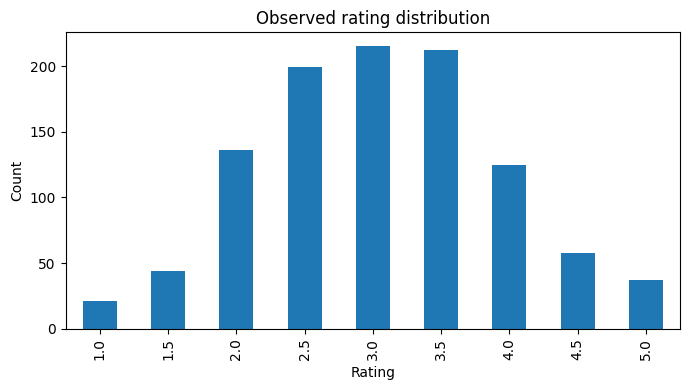

In [7]:
ratings_per_user = ratings_matrix.notna().sum(axis=1)
ratings_per_item = ratings_matrix.notna().sum(axis=0)

plt.figure(figsize=(7, 4))
ratings_long["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Observed rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

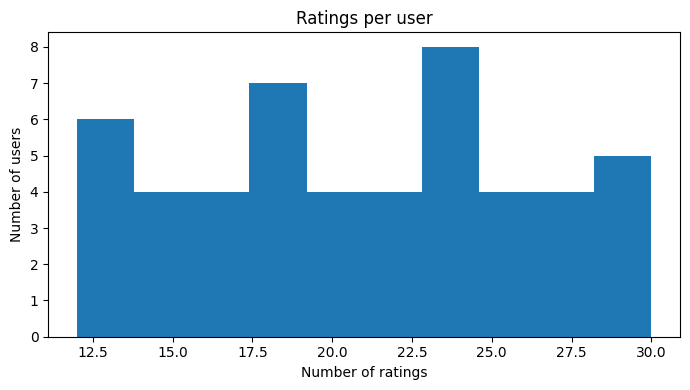

In [8]:
plt.figure(figsize=(7, 4))
ratings_per_user.plot(kind="hist", bins=10)
plt.title("Ratings per user")
plt.xlabel("Number of ratings")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

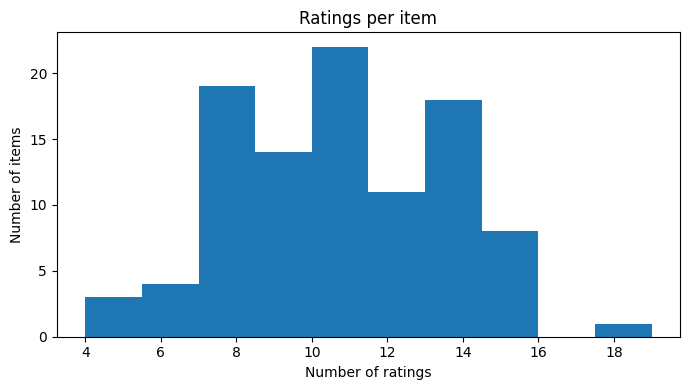

In [9]:
plt.figure(figsize=(7, 4))
ratings_per_item.plot(kind="hist", bins=10)
plt.title("Ratings per item")
plt.xlabel("Number of ratings")
plt.ylabel("Number of items")
plt.tight_layout()
plt.show()

## 7. Visualize the sparse user–item matrix

A dark cell means a rating is present.  
A light cell means the interaction is missing.

This visual immediately shows why recommendation systems are difficult: most of the matrix is unknown.

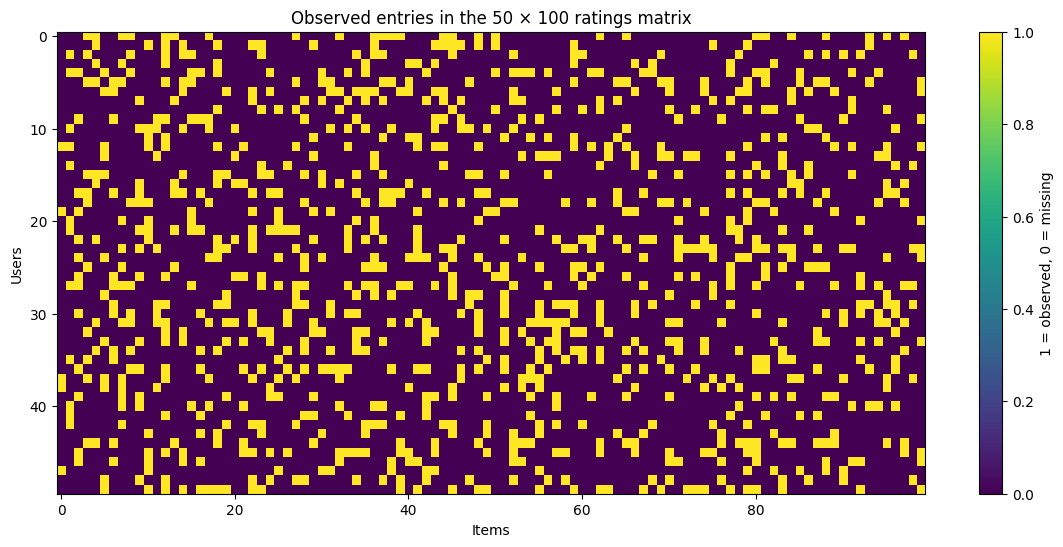

In [10]:
plt.figure(figsize=(14, 6))
plt.imshow(
    ratings_matrix.notna().astype(int),
    aspect="auto",
)
plt.title("Observed entries in the 50 × 100 ratings matrix")
plt.xlabel("Items")
plt.ylabel("Users")
plt.colorbar(label="1 = observed, 0 = missing")
plt.show()

# Part A — Simple baselines

Before building collaborative filtering, we need simple baselines.

A complex model should beat a simple recommendation rule.  
Otherwise, the additional complexity may not be justified.

## 8. Global mean, user mean, and item mean

Three simple estimates are:

1. **Global mean**: average rating across the entire dataset
2. **User mean**: average rating given by one user
3. **Item mean**: average rating received by one item

In [11]:
global_mean = ratings_long["rating"].mean()
user_means = ratings_matrix.mean(axis=1)
item_means = ratings_matrix.mean(axis=0)

print("Global mean rating:", round(global_mean, 3))
print()
print("First 8 user means:")
display(user_means.head(8).rename("mean_rating").to_frame())

print("First 8 item means:")
display(item_means.head(8).rename("mean_rating").to_frame())

Global mean rating: 3.046

First 8 user means:


,mean_rating
U01,2.942
U02,2.684
U03,3.190
U04,3.231
U05,2.926
U06,3.500
U07,2.538
U08,3.263


First 8 item means:


,mean_rating
I001,3.000
I002,1.917
I003,2.654
I004,3.364
I005,2.850
I006,2.667
I007,2.625
I008,3.577


## 9. Popularity-based recommendation

A naive popularity recommender ranks items by average rating.

However, an item with one rating of 5.0 should not automatically outrank an item with twenty ratings averaging 4.7.

We therefore use a simple Bayesian-style weighted score:

\[
\text{weighted score}
=
\frac{v}{v+m}R
+
\frac{m}{v+m}C
\]

where:

- \(R\) = item average rating
- \(v\) = number of ratings for the item
- \(C\) = global average rating
- \(m\) = minimum confidence threshold

In [12]:
item_stats = pd.DataFrame({
    "rating_count": ratings_matrix.count(axis=0),
    "mean_rating": ratings_matrix.mean(axis=0),
})
item_stats.index.name = "item_id"

m = 8
C = global_mean

item_stats["weighted_score"] = (
    (
        item_stats["rating_count"]
        / (item_stats["rating_count"] + m)
    )
    * item_stats["mean_rating"]
    + (
        m
        / (item_stats["rating_count"] + m)
    )
    * C
)

popular_items = (
    item_stats
    .join(item_metadata.set_index("item_id"))
    .sort_values(
        "weighted_score",
        ascending=False,
    )
)

popular_items.head(10)

,rating_count,mean_rating,weighted_score,category,price_band,is_new_item
item_id,,,,,,
I010,13,3.769,3.494,Action,Low,False
I082,13,3.769,3.494,Documentary,High,False
I099,7,4.000,3.491,Technology,Medium,False
I049,15,3.600,3.407,Technology,Low,False
I047,10,3.650,3.382,Documentary,Medium,False
I046,14,3.571,3.380,Sports,Medium,False
I043,13,3.577,3.375,Technology,Medium,False
I008,13,3.577,3.375,Technology,Medium,False
I086,9,3.667,3.375,Technology,Low,False


### When popularity recommendations are useful

Popularity is useful for:

- A completely new user
- A new region
- A platform with little interaction data
- A fallback when a personalized model fails
- A homepage where some globally popular content is desirable

Its main limitation is that it gives nearly the same recommendations to everyone.

# Part B — Train/test split

We now hide some known ratings and ask the algorithms to predict them.

For each user:

- 80% of observed ratings remain in training
- 20% become test ratings

This simulates the real task:

> Can the model predict an interaction that it has not seen?

In [13]:
train_matrix = ratings_matrix.copy()
test_rows = []

for user_id in user_ids:
    rated_items = (
        ratings_matrix
        .loc[user_id]
        .dropna()
        .index
        .to_numpy()
    )

    n_test = max(
        1,
        int(round(0.20 * len(rated_items))),
    )

    chosen_test_items = rng.choice(
        rated_items,
        size=n_test,
        replace=False,
    )

    for item_id in chosen_test_items:
        test_rows.append({
            "user_id": user_id,
            "item_id": item_id,
            "rating": ratings_matrix.loc[user_id, item_id],
        })

        train_matrix.loc[user_id, item_id] = np.nan

test_data = pd.DataFrame(test_rows)

print(
    "Training ratings:",
    int(train_matrix.notna().sum().sum()),
)
print("Test ratings:", len(test_data))

test_data.head(10)

Training ratings: 835
Test ratings: 212


,user_id,item_id,rating
0,U01,I063,3.5
1,U01,I039,1.5
2,U01,I018,3.0
3,U01,I008,4.0
4,U01,I098,2.0
5,U02,I005,2.5
6,U02,I013,2.5
7,U02,I080,3.0
8,U02,I060,2.0
9,U03,I099,4.5


## 10. Evaluation metric: RMSE

Root Mean Squared Error is:

\[
RMSE
=
\sqrt{
\frac{1}{n}
\sum_{j=1}^{n}
(\hat{r}_j-r_j)^2
}
\]

A lower RMSE means predicted ratings are closer to actual hidden ratings.

In [14]:
def rmse(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    return np.sqrt(
        np.mean((actual - predicted) ** 2)
    )

# Part C — Cosine similarity from first principles

## 11. Cosine similarity

For two vectors \(a\) and \(b\):

\[
\text{cosine similarity}(a,b)
=
\frac{a \cdot b}{||a|| \, ||b||}
\]

It measures whether two vectors point in a similar direction.

- Similarity near `1`: highly similar
- Similarity near `0`: little shared direction
- Similarity near `-1`: opposite direction

For recommendation systems, we must also think carefully about missing values and rating scale.

In [15]:
def cosine_similarity_matrix(matrix):
    matrix = np.asarray(
        matrix,
        dtype=float,
    )

    dot_products = matrix @ matrix.T

    norms = np.sqrt(
        np.sum(matrix ** 2, axis=1)
    )

    denominator = (
        norms[:, None]
        * norms[None, :]
    )

    similarity = np.divide(
        dot_products,
        denominator,
        out=np.zeros_like(dot_products),
        where=denominator != 0,
    )

    return similarity

# Part D — User–user collaborative filtering

## 12. User–user collaborative filtering intuition

The process is:

1. Choose a target user.
2. Compare that user with every other user.
3. Find users with similar rating patterns.
4. Look at items those similar users rated.
5. Predict how the target user may rate unseen items.

A simple issue is that different users have different rating habits:

- One user may rate almost everything 5.
- Another may use mostly 2, 3, and 4.

To reduce this effect, we subtract each user's mean rating before calculating similarity.

In [16]:
train_user_means = train_matrix.mean(axis=1)

user_centered = train_matrix.sub(
    train_user_means,
    axis=0,
)

user_centered_filled = user_centered.fillna(0)

user_similarity_values = cosine_similarity_matrix(
    user_centered_filled.values
)

user_similarity = pd.DataFrame(
    user_similarity_values,
    index=user_ids,
    columns=user_ids,
)

np.fill_diagonal(
    user_similarity.values,
    0,
)

user_similarity.iloc[:8, :8]

,U01,U02,U03,U04,U05,U06,U07,U08
U01,0.000,-0.147,-0.082,-0.019,0.033,-0.162,-0.074,0.232
U02,-0.147,0.000,0.016,-0.009,-0.137,0.047,0.262,0.158
U03,-0.082,0.016,0.000,0.004,0.088,0.077,-0.174,-0.115
U04,-0.019,-0.009,0.004,0.000,-0.011,0.007,0.000,-0.051
U05,0.033,-0.137,0.088,-0.011,0.000,0.030,-0.019,0.011
U06,-0.162,0.047,0.077,0.007,0.030,0.000,0.077,-0.069
U07,-0.074,0.262,-0.174,0.000,-0.019,0.077,0.000,0.097
U08,0.232,0.158,-0.115,-0.051,0.011,-0.069,0.097,0.000


## 13. Inspect similar users

We choose one target user and rank the other users by cosine similarity.

In [17]:
TARGET_USER = "U01"

similar_users_to_target = (
    user_similarity
    .loc[TARGET_USER]
    .sort_values(ascending=False)
    .rename("similarity")
    .to_frame()
)

similar_users_to_target.head(10)

,similarity
U42,0.291
U40,0.233
U08,0.232
U46,0.226
U50,0.153
U26,0.145
U13,0.135
U09,0.123
U27,0.117
U30,0.095


## 14. Predict one rating with user–user collaborative filtering

For user \(u\) and item \(i\):

\[
\hat r_{ui}
=
\bar r_u
+
\frac{
\sum_{v \in N(u)}
s(u,v)(r_{vi}-\bar r_v)
}{
\sum_{v \in N(u)} |s(u,v)|
}
\]

where:

- \(\bar r_u\) is the target user's average rating
- \(N(u)\) is the set of similar users
- \(s(u,v)\) is similarity between users
- \(r_{vi}-\bar r_v\) is how much user \(v\)'s rating differs from their own average

In [18]:
def predict_user_user(
    user_id,
    item_id,
    ratings,
    similarities,
    neighbor_count=10,
):
    user_mean = ratings.loc[user_id].mean()

    users_who_rated_item = (
        ratings[item_id]
        .dropna()
        .index
    )

    candidate_similarities = (
        similarities
        .loc[user_id, users_who_rated_item]
        .sort_values(ascending=False)
    )

    neighbors = candidate_similarities.head(
        neighbor_count
    )

    numerator = 0.0
    denominator = 0.0

    for neighbor_id, similarity in neighbors.items():
        neighbor_rating = ratings.loc[
            neighbor_id,
            item_id,
        ]

        neighbor_mean = ratings.loc[
            neighbor_id
        ].mean()

        numerator += (
            similarity
            * (neighbor_rating - neighbor_mean)
        )

        denominator += abs(similarity)

    if denominator == 0:
        return float(user_mean)

    prediction = (
        user_mean
        + numerator / denominator
    )

    return float(
        np.clip(prediction, 1.0, 5.0)
    )

In [19]:
sample_test_case = test_data.iloc[0]

sample_user = sample_test_case["user_id"]
sample_item = sample_test_case["item_id"]
actual_rating = sample_test_case["rating"]

predicted_rating = predict_user_user(
    sample_user,
    sample_item,
    train_matrix,
    user_similarity,
    neighbor_count=10,
)

print("User:", sample_user)
print("Item:", sample_item)
print("Actual hidden rating:", actual_rating)
print(
    "User-user predicted rating:",
    round(predicted_rating, 3),
)

User: U01
Item: I063
Actual hidden rating: 3.5
User-user predicted rating: 3.095


## 15. Show the neighbor contributions for one prediction

This makes the prediction explainable.

In [20]:
def user_user_explanation(
    user_id,
    item_id,
    ratings,
    similarities,
    neighbor_count=10,
):
    users_who_rated_item = (
        ratings[item_id]
        .dropna()
        .index
    )

    candidate_similarities = (
        similarities
        .loc[user_id, users_who_rated_item]
    )

    neighbors = (
        candidate_similarities
        .sort_values(ascending=False)
        .head(neighbor_count)
    )

    rows = []

    for neighbor_id, similarity in neighbors.items():
        neighbor_rating = ratings.loc[
            neighbor_id,
            item_id,
        ]

        neighbor_mean = ratings.loc[
            neighbor_id
        ].mean()

        deviation = (
            neighbor_rating
            - neighbor_mean
        )

        weighted_deviation = (
            similarity
            * deviation
        )

        rows.append({
            "neighbor": neighbor_id,
            "similarity": similarity,
            "neighbor_rating": neighbor_rating,
            "neighbor_mean": neighbor_mean,
            "rating_deviation": deviation,
            "weighted_deviation": weighted_deviation,
        })

    return pd.DataFrame(rows)

user_user_explanation(
    sample_user,
    sample_item,
    train_matrix,
    user_similarity,
    neighbor_count=10,
)

,neighbor,similarity,neighbor_rating,neighbor_mean,rating_deviation,weighted_deviation
0,U08,0.232,3.0,3.267,-0.267,-0.062
1,U46,0.226,4.0,2.818,1.182,0.267
2,U50,0.153,1.5,2.167,-0.667,-0.102
3,U26,0.145,3.0,2.438,0.562,0.081
4,U09,0.123,3.0,2.857,0.143,0.018
5,U30,0.095,3.0,3.316,-0.316,-0.030
6,U15,0.085,2.5,2.950,-0.450,-0.038
7,U05,0.033,3.0,2.886,0.114,0.004
8,U45,-0.017,3.0,3.114,-0.114,0.002
9,U22,-0.025,2.5,2.281,0.219,-0.005


## 16. Generate Top-N user–user recommendations

We score every item the user has not rated and rank the predictions.

In [21]:
def recommend_user_user(
    user_id,
    ratings,
    similarities,
    neighbor_count=10,
    top_n=10,
):
    unseen_items = (
        ratings
        .loc[user_id]
        [ratings.loc[user_id].isna()]
        .index
    )

    predictions = []

    for item_id in unseen_items:
        predicted_rating = predict_user_user(
            user_id,
            item_id,
            ratings,
            similarities,
            neighbor_count=neighbor_count,
        )

        predictions.append({
            "item_id": item_id,
            "predicted_rating": predicted_rating,
        })

    recommendations = (
        pd.DataFrame(predictions)
        .merge(
            item_metadata,
            on="item_id",
            how="left",
        )
        .sort_values(
            "predicted_rating",
            ascending=False,
        )
        .head(top_n)
    )

    return recommendations

recommend_user_user(
    TARGET_USER,
    train_matrix,
    user_similarity,
    neighbor_count=10,
    top_n=10,
)

,item_id,predicted_rating,category,price_band,is_new_item
49,I064,4.115,Sports,Medium,False
47,I062,3.918,Technology,Low,False
6,I010,3.889,Action,Low,False
78,I100,3.858,Comedy,Low,False
65,I083,3.726,Comedy,Medium,False
46,I061,3.531,Sports,Medium,False
9,I015,3.526,Technology,Medium,False
45,I060,3.482,Technology,High,False
60,I076,3.472,Documentary,Medium,False
62,I078,3.457,Comedy,Low,False


## 17. Evaluate user–user collaborative filtering

In [22]:
user_user_predictions = []

for row in test_data.itertuples(index=False):
    prediction = predict_user_user(
        row.user_id,
        row.item_id,
        train_matrix,
        user_similarity,
        neighbor_count=10,
    )

    user_user_predictions.append(prediction)

user_user_rmse = rmse(
    test_data["rating"],
    user_user_predictions,
)

print(
    "User-user CF RMSE:",
    round(user_user_rmse, 4),
)

User-user CF RMSE: 0.7741


### User–user collaborative filtering: strengths and limitations

**Strengths**

- Easy to explain
- Uses collective behavior
- Can discover unexpected items
- Does not require detailed item metadata

**Limitations**

- User preferences can change quickly
- Similarity calculations become expensive with millions of users
- Sparse overlap can make similarities unreliable
- New users have insufficient interaction history

# Part E — Item–item collaborative filtering

## 18. Item–item collaborative filtering intuition

Instead of asking:

> Which users are similar to this user?

we ask:

> Which items have similar rating patterns?

For example:

- Users who liked Item A also tended to like Item B.
- Users who disliked Item A also tended to dislike Item B.

Items are often more stable than users, and item similarities can be precomputed.

## 19. Construct item vectors

For item–item similarity, each item is represented by its ratings across users.

We again subtract each user's average rating before comparing items.  
This is often called **adjusted cosine similarity**.

In [23]:
item_vectors = (
    train_matrix
    .sub(train_user_means, axis=0)
    .T
    .fillna(0)
)

item_vectors.iloc[:8, :10]

,U01,U02,U03,U04,U05,U06,U07,U08,U09,U10
item_id,,,,,,,,,,
I001,0.000,0.0,0.000,0.00,0.000,0.000,0.000,0.0,0.0,0.0
I002,0.000,0.0,-1.029,0.00,-1.386,0.000,0.000,0.0,0.0,0.0
I003,0.000,0.0,0.000,0.00,0.000,0.000,0.000,0.0,0.0,-1.1
I004,-0.476,0.0,0.971,0.00,0.000,0.523,0.000,0.0,0.0,0.0
I005,1.024,0.0,0.000,-0.05,0.000,0.000,0.000,0.0,0.0,0.0
I006,0.000,0.0,0.000,0.00,-0.386,0.000,-0.476,0.0,0.0,0.0
I007,0.000,0.0,0.000,0.00,0.000,0.023,0.000,0.0,0.0,0.0
I008,0.000,0.0,0.000,1.45,0.000,0.023,0.000,0.0,0.0,0.0


In [24]:
item_similarity_values = cosine_similarity_matrix(
    item_vectors.values
)

item_similarity = pd.DataFrame(
    item_similarity_values,
    index=item_ids,
    columns=item_ids,
)

np.fill_diagonal(
    item_similarity.values,
    0,
)

item_similarity.iloc[:10, :10]

,I001,I002,I003,I004,I005,I006,I007,I008,I009,I010
I001,0.000,0.146,0.000,0.000,0.000,-0.085,0.000e+00,-2.015e-01,0.000,0.000
I002,0.146,0.000,0.031,-0.107,0.000,0.055,6.674e-02,-3.069e-02,-0.215,-0.137
I003,0.000,0.031,0.000,-0.039,0.000,0.011,2.342e-01,0.000e+00,-0.015,0.152
I004,0.000,-0.107,-0.039,0.000,-0.401,0.000,-2.443e-02,7.805e-03,0.268,-0.044
I005,0.000,0.000,0.000,-0.401,0.000,0.000,-1.588e-02,-1.583e-02,-0.171,-0.008
I006,-0.085,0.055,0.011,0.000,0.000,0.000,0.000e+00,-2.036e-01,-0.089,-0.214
I007,0.000,0.067,0.234,-0.024,-0.016,0.000,0.000e+00,1.297e-04,0.078,-0.216
I008,-0.202,-0.031,0.000,0.008,-0.016,-0.204,1.297e-04,0.000e+00,-0.022,0.198
I009,0.000,-0.215,-0.015,0.268,-0.171,-0.089,7.813e-02,-2.235e-02,0.000,0.000
I010,0.000,-0.137,0.152,-0.044,-0.008,-0.214,-2.160e-01,1.981e-01,0.000,0.000


## 20. Inspect items similar to one item

In [25]:
TARGET_ITEM = "I001"

similar_items_to_target = (
    item_similarity
    .loc[TARGET_ITEM]
    .sort_values(ascending=False)
    .rename("similarity")
    .to_frame()
    .join(
        item_metadata.set_index("item_id")
    )
)

similar_items_to_target.head(10)

,similarity,category,price_band,is_new_item
I028,0.367,Travel,Medium,False
I090,0.354,Travel,Low,False
I073,0.289,Documentary,Low,False
I042,0.267,Travel,Medium,False
I086,0.253,Technology,Low,False
I085,0.230,Technology,Medium,False
I065,0.222,Documentary,Low,False
I022,0.204,Drama,Medium,False
I078,0.195,Comedy,Low,False
I047,0.178,Documentary,Medium,False


## 21. Visualize a small item-similarity heatmap

We display only the first 20 items so the labels remain readable.

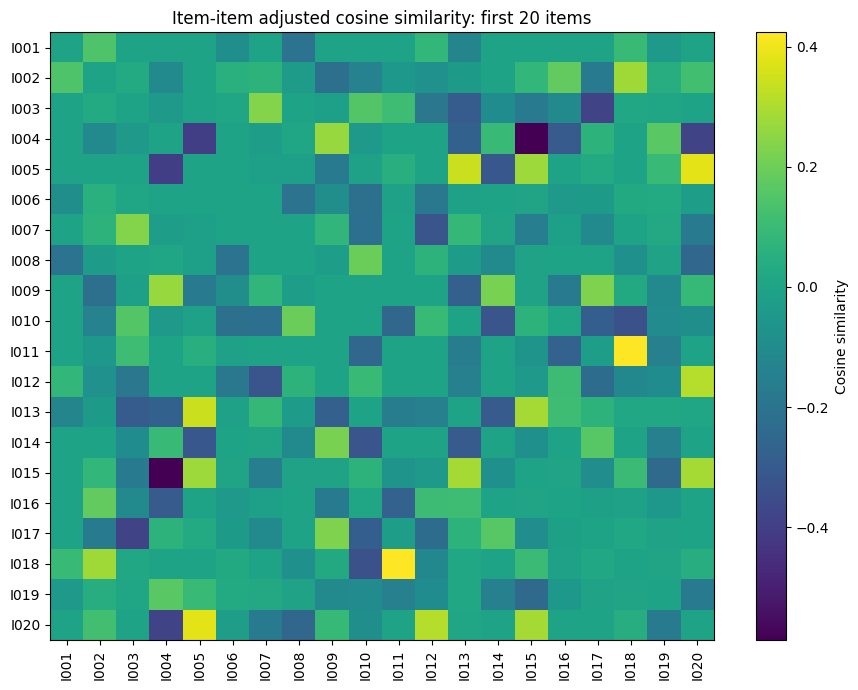

In [26]:
subset_items = item_ids[:20]

subset_similarity = item_similarity.loc[
    subset_items,
    subset_items,
]

plt.figure(figsize=(9, 7))
plt.imshow(
    subset_similarity.values,
    aspect="auto",
)
plt.title(
    "Item-item adjusted cosine similarity: first 20 items"
)
plt.xticks(
    range(len(subset_items)),
    subset_items,
    rotation=90,
)
plt.yticks(
    range(len(subset_items)),
    subset_items,
)
plt.colorbar(label="Cosine similarity")
plt.tight_layout()
plt.show()

## 22. Predict one rating with item–item collaborative filtering

For user \(u\) and candidate item \(i\), we look at items already rated by the user.

A mean-centered prediction is:

\[
\hat r_{ui}
=
\bar r_u
+
\frac{
\sum_{j \in N(i)}
s(i,j)(r_{uj}-\bar r_u)
}{
\sum_{j \in N(i)} |s(i,j)|
}
\]

where \(N(i)\) contains items similar to candidate item \(i\) that the user has already rated.

In [27]:
def predict_item_item(
    user_id,
    item_id,
    ratings,
    similarities,
    neighbor_count=10,
):
    user_mean = ratings.loc[user_id].mean()

    rated_items = (
        ratings
        .loc[user_id]
        .dropna()
        .index
    )

    candidate_similarities = (
        similarities
        .loc[item_id, rated_items]
        .sort_values(ascending=False)
    )

    neighbors = candidate_similarities.head(
        neighbor_count
    )

    numerator = 0.0
    denominator = 0.0

    for neighbor_item, similarity in neighbors.items():
        user_rating = ratings.loc[
            user_id,
            neighbor_item,
        ]

        deviation = (
            user_rating
            - user_mean
        )

        numerator += (
            similarity
            * deviation
        )

        denominator += abs(similarity)

    if denominator == 0:
        return float(user_mean)

    prediction = (
        user_mean
        + numerator / denominator
    )

    return float(
        np.clip(prediction, 1.0, 5.0)
    )

In [28]:
item_item_prediction = predict_item_item(
    sample_user,
    sample_item,
    train_matrix,
    item_similarity,
    neighbor_count=10,
)

print("User:", sample_user)
print("Item:", sample_item)
print("Actual hidden rating:", actual_rating)
print(
    "Item-item predicted rating:",
    round(item_item_prediction, 3),
)

User: U01
Item: I063
Actual hidden rating: 3.5
Item-item predicted rating: 3.627


## 23. Explain the item contributions

This table shows which previously rated items influenced the candidate score.

In [29]:
def item_item_explanation(
    user_id,
    item_id,
    ratings,
    similarities,
    neighbor_count=10,
):
    user_mean = ratings.loc[user_id].mean()

    rated_items = (
        ratings
        .loc[user_id]
        .dropna()
        .index
    )

    candidate_similarities = similarities.loc[
        item_id,
        rated_items,
    ]

    neighbors = (
        candidate_similarities
        .sort_values(ascending=False)
        .head(neighbor_count)
    )

    rows = []

    for neighbor_item, similarity in neighbors.items():
        user_rating = ratings.loc[
            user_id,
            neighbor_item,
        ]

        deviation = (
            user_rating
            - user_mean
        )

        weighted_deviation = (
            similarity
            * deviation
        )

        rows.append({
            "neighbor_item": neighbor_item,
            "similarity": similarity,
            "user_rating": user_rating,
            "user_mean": user_mean,
            "rating_deviation": deviation,
            "weighted_deviation": weighted_deviation,
        })

    return (
        pd.DataFrame(rows)
        .merge(
            item_metadata,
            left_on="neighbor_item",
            right_on="item_id",
            how="left",
        )
        .drop(columns="item_id")
    )

item_item_explanation(
    sample_user,
    sample_item,
    train_matrix,
    item_similarity,
    neighbor_count=10,
)

,neighbor_item,similarity,user_rating,user_mean,rating_deviation,weighted_deviation,category,price_band,is_new_item
0,I013,0.342,5.0,2.976,2.024,6.913e-01,Technology,Medium,False
1,I009,0.210,2.5,2.976,-0.476,-1.002e-01,Comedy,Low,False
2,I089,0.180,3.0,2.976,0.024,4.284e-03,Travel,Medium,False
3,I033,0.101,2.5,2.976,-0.476,-4.793e-02,Action,High,False
4,I005,0.094,4.0,2.976,1.024,9.596e-02,Documentary,Medium,False
5,I082,0.066,4.0,2.976,1.024,6.777e-02,Documentary,High,False
6,I028,0.017,2.5,2.976,-0.476,-7.908e-03,Travel,Medium,False
7,I051,0.011,2.5,2.976,-0.476,-5.074e-03,Travel,High,False
8,I037,-0.014,4.0,2.976,1.024,-1.484e-02,Travel,Medium,False
9,I085,-0.015,3.0,2.976,0.024,-3.557e-04,Technology,Medium,False


## 24. Generate Top-N item–item recommendations

In [30]:
def recommend_item_item(
    user_id,
    ratings,
    similarities,
    neighbor_count=10,
    top_n=10,
):
    unseen_items = (
        ratings
        .loc[user_id]
        [ratings.loc[user_id].isna()]
        .index
    )

    predictions = []

    for item_id in unseen_items:
        predicted_rating = predict_item_item(
            user_id,
            item_id,
            ratings,
            similarities,
            neighbor_count=neighbor_count,
        )

        predictions.append({
            "item_id": item_id,
            "predicted_rating": predicted_rating,
        })

    recommendations = (
        pd.DataFrame(predictions)
        .merge(
            item_metadata,
            on="item_id",
            how="left",
        )
        .sort_values(
            "predicted_rating",
            ascending=False,
        )
        .head(top_n)
    )

    return recommendations

recommend_item_item(
    TARGET_USER,
    train_matrix,
    item_similarity,
    neighbor_count=10,
    top_n=10,
)

,item_id,predicted_rating,category,price_band,is_new_item
78,I100,4.204,Comedy,Low,False
26,I034,4.171,Food,Low,False
56,I072,3.775,Comedy,Medium,False
9,I015,3.754,Technology,Medium,False
49,I064,3.745,Sports,Medium,False
48,I063,3.627,Drama,Low,False
10,I016,3.601,Travel,Medium,False
35,I048,3.564,Sports,Low,False
21,I027,3.553,Documentary,Low,False
47,I062,3.538,Technology,Low,False


## 25. Evaluate item–item collaborative filtering

In [31]:
item_item_predictions = []

for row in test_data.itertuples(index=False):
    prediction = predict_item_item(
        row.user_id,
        row.item_id,
        train_matrix,
        item_similarity,
        neighbor_count=10,
    )

    item_item_predictions.append(prediction)

item_item_rmse = rmse(
    test_data["rating"],
    item_item_predictions,
)

print(
    "Item-item CF RMSE:",
    round(item_item_rmse, 4),
)

Item-item CF RMSE: 0.8306


### Why item–item collaborative filtering is popular in industry

- Item relationships are often more stable than user relationships.
- Similar items can be precomputed periodically.
- Serving recommendations is fast.
- Explanations are intuitive: “Because you liked X.”
- It can work well when the number of items is manageable.

However, it still struggles with completely new items and extremely sparse catalogues.

# Part F — Matrix factorization

## 26. Core matrix-factorization idea

The observed rating matrix has shape:

\[
R \in \mathbb{R}^{50 \times 100}
\]

Matrix factorization approximates it using two smaller matrices:

\[
R \approx P Q^T
\]

where:

- \(P \in \mathbb{R}^{50 \times k}\) contains user latent factors
- \(Q \in \mathbb{R}^{100 \times k}\) contains item latent factors
- \(k\) is much smaller than 50 or 100

For example, with \(k=8\):

- `P` has shape `50 × 8`
- `Q` has shape `100 × 8`
- `P @ Q.T` reconstructs a `50 × 100` score matrix

The latent factors are learned from rating patterns.  
They may represent hidden concepts such as:

- Serious versus light content
- Mainstream versus niche taste
- Expensive versus budget preference
- Fast-paced versus slow-paced content

The algorithm is not explicitly told these meanings.

## 27. Prediction model with biases

We use a practical matrix-factorization model:

\[
\hat r_{ui}
=
\mu
+
b_u
+
b_i
+
p_u \cdot q_i
\]

where:

- \(\mu\) is the global mean
- \(b_u\) is a user bias
- \(b_i\) is an item bias
- \(p_u\) is the user's latent-factor vector
- \(q_i\) is the item's latent-factor vector

We train only on observed ratings.

In [32]:
user_to_index = {
    user_id: index
    for index, user_id in enumerate(user_ids)
}

item_to_index = {
    item_id: index
    for index, item_id in enumerate(item_ids)
}

train_triplets = (
    train_matrix
    .stack()
    .rename("rating")
    .reset_index()
    .rename(columns={
        "level_0": "user_id",
        "level_1": "item_id",
    })
)

train_triplets["user_index"] = (
    train_triplets["user_id"]
    .map(user_to_index)
)

train_triplets["item_index"] = (
    train_triplets["item_id"]
    .map(item_to_index)
)

train_triplets.head(10)

,user_id,item_id,rating,user_index,item_index
0,U01,I004,2.5,0,3
1,U01,I005,4.0,0,4
2,U01,I009,2.5,0,8
3,U01,I013,5.0,0,12
4,U01,I014,1.5,0,13
5,U01,I028,2.5,0,27
6,U01,I033,2.5,0,32
7,U01,I037,4.0,0,36
8,U01,I038,3.5,0,37
9,U01,I040,2.0,0,39


## 28. Initialize the factor matrices

We use 8 latent factors.

Initially:

- User factors are small random numbers
- Item factors are small random numbers
- User and item biases start at zero

In [33]:
N_FACTORS = 8
LEARNING_RATE = 0.01
REGULARIZATION = 0.03
EPOCHS = 60

mf_rng = np.random.default_rng(
    RANDOM_SEED
)

P = mf_rng.normal(
    0,
    0.1,
    size=(N_USERS, N_FACTORS),
)

Q = mf_rng.normal(
    0,
    0.1,
    size=(N_ITEMS, N_FACTORS),
)

user_bias_mf = np.zeros(N_USERS)
item_bias_mf = np.zeros(N_ITEMS)

mf_global_mean = (
    train_triplets["rating"].mean()
)

print("P shape:", P.shape)
print("Q shape:", Q.shape)
print(
    "Reconstructed matrix shape:",
    (P @ Q.T).shape,
)

P shape: (50, 8)
Q shape: (100, 8)
Reconstructed matrix shape: (50, 100)


In [34]:
P_preview = pd.DataFrame(
    P,
    index=user_ids,
    columns=[
        f"factor_{j+1}"
        for j in range(N_FACTORS)
    ],
)

Q_preview = pd.DataFrame(
    Q,
    index=item_ids,
    columns=[
        f"factor_{j+1}"
        for j in range(N_FACTORS)
    ],
)

print("Initial user-factor matrix P:")
display(P_preview.head())

print("Initial item-factor matrix Q:")
display(Q_preview.head())

Initial user-factor matrix P:


,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8
U01,0.030,-0.104,0.075,0.094,-0.195,-0.130,0.013,-0.032
U02,-0.002,-0.085,0.088,0.078,0.007,0.113,0.047,-0.086
U03,0.037,-0.096,0.088,-0.005,-0.018,-0.068,0.122,-0.015
U04,-0.043,-0.035,0.053,0.037,0.041,0.043,0.214,-0.041
U05,-0.051,-0.081,0.062,0.113,-0.011,-0.084,-0.082,0.065


Initial item-factor matrix Q:


,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8
I001,-0.018,0.020,0.082,-0.039,0.052,-0.027,-0.012,0.083
I002,-0.199,-0.130,-0.148,-0.233,-0.068,0.075,-0.028,0.020
I003,0.109,0.133,-0.007,0.135,0.009,-0.084,-0.059,-0.148
I004,-0.089,-0.036,0.080,0.172,-0.138,0.039,-0.104,0.047
I005,-0.013,-0.183,0.093,-0.061,-0.053,-0.107,-0.065,0.043


## 29. Train with stochastic gradient descent

For one observed rating:

1. Predict the rating.
2. Compute the error.
3. Move the user and item factors slightly in a direction that reduces the error.
4. Apply regularization to discourage excessively large parameter values.

The squared-error objective is approximately:

\[
(r_{ui}-\hat r_{ui})^2
+
\lambda
\left(
||p_u||^2
+
||q_i||^2
+
b_u^2
+
b_i^2
\right)
\]

In [35]:
training_history = []

training_array = train_triplets[
    [
        "user_index",
        "item_index",
        "rating",
    ]
].to_numpy()

for epoch in range(EPOCHS):
    shuffled_indices = mf_rng.permutation(
        len(training_array)
    )

    squared_error_sum = 0.0

    for row_index in shuffled_indices:
        user_index, item_index, rating = (
            training_array[row_index]
        )

        user_index = int(user_index)
        item_index = int(item_index)

        prediction = (
            mf_global_mean
            + user_bias_mf[user_index]
            + item_bias_mf[item_index]
            + P[user_index] @ Q[item_index]
        )

        error = rating - prediction
        squared_error_sum += error ** 2

        user_vector_before_update = (
            P[user_index].copy()
        )

        user_bias_mf[user_index] += (
            LEARNING_RATE
            * (
                error
                - REGULARIZATION
                * user_bias_mf[user_index]
            )
        )

        item_bias_mf[item_index] += (
            LEARNING_RATE
            * (
                error
                - REGULARIZATION
                * item_bias_mf[item_index]
            )
        )

        P[user_index] += (
            LEARNING_RATE
            * (
                error * Q[item_index]
                - REGULARIZATION
                * P[user_index]
            )
        )

        Q[item_index] += (
            LEARNING_RATE
            * (
                error * user_vector_before_update
                - REGULARIZATION
                * Q[item_index]
            )
        )

    epoch_rmse = np.sqrt(
        squared_error_sum
        / len(training_array)
    )

    training_history.append(
        epoch_rmse
    )

print(
    "Final training RMSE:",
    round(training_history[-1], 4),
)

Final training RMSE: 0.4601


## 30. Plot the training loss

The curve should generally decrease as the model learns.

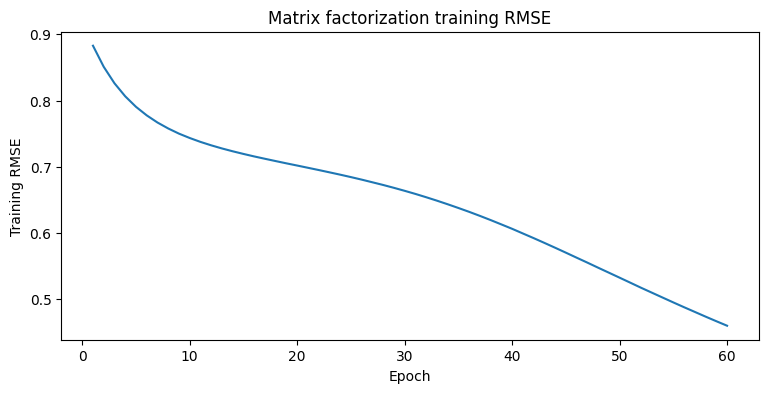

In [36]:
plt.figure(figsize=(9, 4))
plt.plot(
    range(1, EPOCHS + 1),
    training_history,
)
plt.title(
    "Matrix factorization training RMSE"
)
plt.xlabel("Epoch")
plt.ylabel("Training RMSE")
plt.show()

## 31. Inspect the learned factor matrices

The matrix shapes do not change:

- `P`: one row per user
- `Q`: one row per item

Only their values are learned.

In [37]:
learned_P = pd.DataFrame(
    P,
    index=user_ids,
    columns=[
        f"factor_{j+1}"
        for j in range(N_FACTORS)
    ],
)

learned_Q = pd.DataFrame(
    Q,
    index=item_ids,
    columns=[
        f"factor_{j+1}"
        for j in range(N_FACTORS)
    ],
)

print("Learned user-factor matrix P:")
display(learned_P.head(8))

print("Learned item-factor matrix Q:")
display(learned_Q.head(8))

Learned user-factor matrix P:


,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8
U01,-0.097,-0.064,-0.412,-0.353,-0.293,-0.364,-0.518,-4.607e-02
U02,-0.211,-0.230,0.181,0.127,0.178,0.866,0.258,-1.090e-02
U03,0.246,-0.410,0.227,0.287,-0.115,-0.903,0.400,-7.694e-03
U04,0.004,-0.199,0.140,0.079,0.145,-0.146,0.153,-1.432e-01
U05,-0.122,-0.011,-0.042,0.098,-0.005,0.081,-0.165,1.784e-01
U06,0.387,-0.143,-0.334,0.021,0.282,0.227,0.719,3.905e-01
U07,0.170,0.206,0.045,0.177,-0.058,0.334,0.082,-8.974e-04
U08,-0.160,0.557,-0.360,0.354,-0.223,0.714,-0.085,-1.374e-01


Learned item-factor matrix Q:


,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8
I001,-0.003,-0.010,0.145,0.014,0.062,0.013,-0.019,0.033
I002,-0.164,-0.127,-0.220,-0.252,0.016,0.035,-0.024,-0.030
I003,0.471,0.074,-0.258,0.525,-0.063,-0.638,-0.393,-0.144
I004,-0.072,-0.082,0.250,0.245,-0.030,0.167,0.389,-0.077
I005,-0.021,-0.263,-0.018,-0.215,-0.212,-0.042,-0.346,0.008
I006,-0.034,0.215,-0.068,0.151,-0.040,-0.185,0.246,-0.131
I007,0.294,0.068,-0.304,-0.109,0.134,0.024,-0.083,-0.225
I008,-0.007,-0.194,0.145,0.001,0.127,-0.379,-0.144,-0.355


## 32. Reconstruct the full predicted matrix

The matrix product creates a score for every user–item pair, including missing entries.

\[
\hat R
=
\mu
+
b_u
+
b_i
+
P Q^T
\]

In [38]:
mf_predictions = (
    mf_global_mean
    + user_bias_mf[:, None]
    + item_bias_mf[None, :]
    + P @ Q.T
)

mf_predictions = np.clip(
    mf_predictions,
    1.0,
    5.0,
)

mf_prediction_matrix = pd.DataFrame(
    mf_predictions,
    index=user_ids,
    columns=item_ids,
)

mf_prediction_matrix.iloc[:8, :12]

,I001,I002,I003,I004,I005,I006,I007,I008,I009,I010,I011,I012
U01,2.759,1.952,2.839,2.877,3.173,2.363,2.743,3.681,2.713,3.468,1.998,2.265
U02,2.648,1.534,1.509,3.417,2.448,2.066,2.248,3.033,2.583,3.065,2.290,3.168
U03,3.098,1.848,3.360,3.704,3.023,2.892,2.731,4.168,3.155,4.024,2.670,3.214
U04,2.876,1.741,2.560,3.432,2.785,2.495,2.595,3.714,2.856,3.528,2.407,3.015
U05,2.866,1.783,2.522,3.286,2.879,2.405,2.570,3.486,2.823,3.584,2.441,2.986
U06,3.331,2.281,2.795,4.010,3.052,3.017,3.227,3.743,3.284,3.958,3.128,3.429
U07,2.559,1.369,2.157,3.134,2.403,2.180,2.347,3.072,2.437,3.154,2.310,2.724
U08,3.125,2.074,2.710,3.717,2.995,2.866,3.041,3.488,3.066,3.688,2.867,3.281


## 33. Compare observed and reconstructed values

The prediction matrix is dense, while the training matrix is sparse.

In [39]:
comparison_items = item_ids[:12]

comparison = pd.DataFrame({
    "observed_train_rating": (
        train_matrix.loc[
            TARGET_USER,
            comparison_items,
        ]
    ),
    "matrix_factorization_prediction": (
        mf_prediction_matrix.loc[
            TARGET_USER,
            comparison_items,
        ]
    ),
})

comparison

,observed_train_rating,matrix_factorization_prediction
I001,NaN,2.759
I002,NaN,1.952
I003,NaN,2.839
I004,2.5,2.877
I005,4.0,3.173
I006,NaN,2.363
I007,NaN,2.743
I008,NaN,3.681
I009,2.5,2.713
I010,NaN,3.468


## 34. Predict one test rating

In [40]:
def predict_matrix_factorization(
    user_id,
    item_id,
):
    return float(
        mf_prediction_matrix.loc[
            user_id,
            item_id,
        ]
    )

mf_sample_prediction = (
    predict_matrix_factorization(
        sample_user,
        sample_item,
    )
)

print("User:", sample_user)
print("Item:", sample_item)
print("Actual hidden rating:", actual_rating)
print(
    "Matrix-factorization prediction:",
    round(mf_sample_prediction, 3),
)

User: U01
Item: I063
Actual hidden rating: 3.5
Matrix-factorization prediction: 2.863


## 35. Generate Top-N matrix-factorization recommendations

In [41]:
def recommend_matrix_factorization(
    user_id,
    ratings,
    prediction_matrix,
    top_n=10,
):
    unseen_items = (
        ratings
        .loc[user_id]
        [ratings.loc[user_id].isna()]
        .index
    )

    recommendations = (
        prediction_matrix
        .loc[user_id, unseen_items]
        .sort_values(ascending=False)
        .head(top_n)
        .rename("predicted_rating")
        .reset_index()
        .rename(columns={"index": "item_id"})
        .merge(
            item_metadata,
            on="item_id",
            how="left",
        )
    )

    return recommendations

recommend_matrix_factorization(
    TARGET_USER,
    train_matrix,
    mf_prediction_matrix,
    top_n=10,
)

,item_id,predicted_rating,category,price_band,is_new_item
0,I060,3.876,Technology,High,False
1,I069,3.837,Action,Medium,False
2,I008,3.681,Technology,Medium,False
3,I052,3.608,Comedy,Medium,False
4,I064,3.540,Sports,Medium,False
5,I043,3.505,Technology,Medium,False
6,I093,3.494,Travel,High,False
7,I048,3.476,Sports,Low,False
8,I010,3.468,Action,Low,False
9,I086,3.432,Technology,Low,False


## 36. Evaluate matrix factorization

In [42]:
mf_test_predictions = [
    predict_matrix_factorization(
        row.user_id,
        row.item_id,
    )
    for row in test_data.itertuples(index=False)
]

mf_rmse = rmse(
    test_data["rating"],
    mf_test_predictions,
)

print(
    "Matrix factorization RMSE:",
    round(mf_rmse, 4),
)

Matrix factorization RMSE: 0.7531


## 37. Interpret latent factors approximately

Latent factors are not automatically labeled.

One practical way to inspect them is to list items with the largest positive values for each factor.

In [43]:
for factor_index in range(3):
    factor_name = (
        f"factor_{factor_index + 1}"
    )

    top_items_for_factor = (
        learned_Q[factor_name]
        .sort_values(ascending=False)
        .head(8)
        .rename("factor_loading")
        .to_frame()
        .join(
            item_metadata.set_index("item_id")
        )
    )

    print(f"Top items for {factor_name}")
    display(top_items_for_factor)

Top items for factor_1


,factor_loading,category,price_band,is_new_item
I039,0.528,Drama,Low,False
I003,0.471,Technology,Medium,False
I025,0.450,Travel,Low,False
I023,0.374,Comedy,High,False
I049,0.342,Technology,Low,False
I088,0.331,Drama,Medium,False
I036,0.319,Action,Low,False
I007,0.294,Action,Medium,False


Top items for factor_2


,factor_loading,category,price_band,is_new_item
I038,0.413,Travel,Medium,False
I011,0.400,Food,Medium,False
I024,0.353,Sports,Low,False
I061,0.306,Sports,Medium,False
I089,0.288,Travel,Medium,False
I031,0.252,Documentary,Medium,False
I057,0.246,Food,Medium,False
I073,0.238,Documentary,Low,False


Top items for factor_3


,factor_loading,category,price_band,is_new_item
I032,0.763,Comedy,Medium,False
I035,0.683,Sports,Low,False
I012,0.577,Sports,Medium,False
I014,0.496,Travel,Medium,False
I049,0.479,Technology,Low,False
I047,0.411,Documentary,Medium,False
I081,0.376,Sports,Low,False
I011,0.365,Food,Medium,False


### Matrix factorization: strengths and limitations

**Strengths**

- Produces a compact representation
- Handles sparse data better than many simple neighborhood methods
- Learns hidden preference dimensions
- Generates scores for all known users and known items
- Often works well as a candidate-generation model

**Limitations**

- Latent factors are difficult to explain
- New users and new items still create cold start
- Hyperparameters matter
- A good RMSE does not guarantee better business outcomes

# Part G — Compare the models

## 38. Global-mean baseline

We compare all models with a very simple baseline that predicts the global average for every test pair.

In [44]:
global_baseline_predictions = np.full(
    len(test_data),
    train_triplets["rating"].mean(),
)

global_baseline_rmse = rmse(
    test_data["rating"],
    global_baseline_predictions,
)

evaluation_table = pd.DataFrame({
    "model": [
        "Global mean baseline",
        "User-user collaborative filtering",
        "Item-item collaborative filtering",
        "Matrix factorization",
    ],
    "RMSE": [
        global_baseline_rmse,
        user_user_rmse,
        item_item_rmse,
        mf_rmse,
    ],
}).sort_values("RMSE")

evaluation_table

,model,RMSE
3,Matrix factorization,0.753
1,User-user collaborative filtering,0.774
2,Item-item collaborative filtering,0.831
0,Global mean baseline,0.869


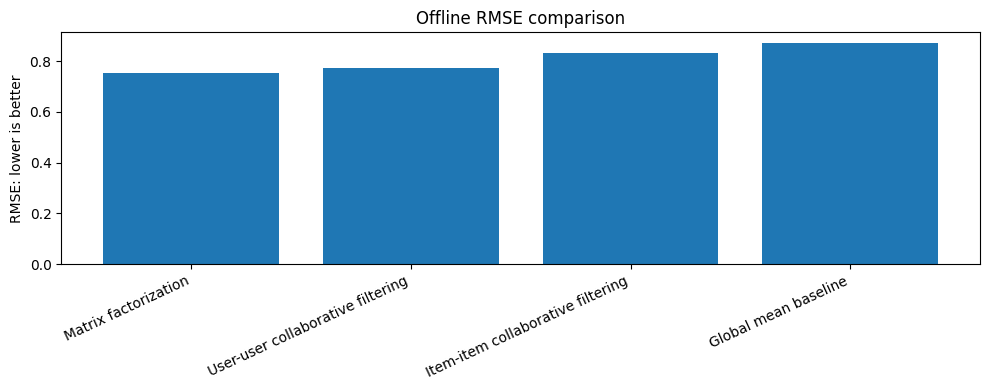

In [45]:
plt.figure(figsize=(10, 4))
plt.bar(
    evaluation_table["model"],
    evaluation_table["RMSE"],
)
plt.title("Offline RMSE comparison")
plt.ylabel("RMSE: lower is better")
plt.xticks(
    rotation=25,
    ha="right",
)
plt.tight_layout()
plt.show()

### Important evaluation warning

RMSE evaluates rating prediction, not the complete recommendation experience.

Production systems also measure:

- Precision@K
- Recall@K
- Hit rate
- NDCG
- Diversity
- Novelty
- Coverage
- Click-through rate
- Conversion rate
- Revenue per session
- Retention

The final business decision should normally be validated through an online experiment.

# Part H — Cold-start handling

## 39. What is cold start?

Three common situations are:

### New user cold start

The platform has little or no history for the user.

### New item cold start

The item has no interactions, so collaborative models cannot learn its relationships.

### New platform cold start

The entire system has insufficient interaction data.

Cold start is usually mitigated, not completely removed.

## 40. New-user fallback with category preferences

Suppose a new user selects three preferred categories during onboarding.

We combine:

- Category preference
- Popularity score

This does not require historical ratings from that new user.

In [46]:
new_user_preferred_categories = [
    "Technology",
    "Travel",
    "Documentary",
]

cold_start_items = (
    popular_items
    .reset_index()
)

cold_start_items["category_match"] = (
    cold_start_items["category"]
    .isin(new_user_preferred_categories)
    .astype(int)
)

cold_start_items["new_user_score"] = (
    0.70
    * cold_start_items["weighted_score"]
    + 0.30
    * cold_start_items["category_match"]
    * 5
)

new_user_recommendations = (
    cold_start_items
    .sort_values(
        "new_user_score",
        ascending=False,
    )
    [[
        "item_id",
        "category",
        "rating_count",
        "mean_rating",
        "weighted_score",
        "category_match",
        "new_user_score",
    ]]
    .head(10)
)

new_user_recommendations

,item_id,category,rating_count,mean_rating,weighted_score,category_match,new_user_score
1,I082,Documentary,13,3.769,3.494,1,3.946
2,I099,Technology,7,4.000,3.491,1,3.944
3,I049,Technology,15,3.600,3.407,1,3.885
4,I047,Documentary,10,3.650,3.382,1,3.867
7,I008,Technology,13,3.577,3.375,1,3.862
6,I043,Technology,13,3.577,3.375,1,3.862
8,I086,Technology,9,3.667,3.375,1,3.862
10,I065,Documentary,8,3.625,3.336,1,3.835
11,I013,Technology,19,3.447,3.329,1,3.830
14,I091,Documentary,8,3.562,3.304,1,3.813


## 41. Content similarity for a new item

Collaborative similarity cannot work for a completely new item.

A simple fallback is to compare item metadata.

Here we use one-hot encoded category and price-band features.

In [47]:
content_features = pd.get_dummies(
    item_metadata
    .set_index("item_id")
    [["category", "price_band"]],
    dtype=float,
)

content_feature_norms = np.sqrt(
    (content_features ** 2)
    .sum(axis=1)
)

content_similarity_values = (
    content_features.values
    @ content_features.values.T
) / (
    content_feature_norms.values[:, None]
    * content_feature_norms.values[None, :]
)

content_similarity = pd.DataFrame(
    content_similarity_values,
    index=item_ids,
    columns=item_ids,
)

content_similarity.iloc[:8, :8]

,I001,I002,I003,I004,I005,I006,I007,I008
I001,1.0,0.5,0.0,0.0,0.0,0.0,0.5,0.0
I002,0.5,1.0,0.0,0.0,0.0,0.5,0.0,0.0
I003,0.0,0.0,1.0,0.5,0.5,0.5,0.5,1.0
I004,0.0,0.0,0.5,1.0,1.0,0.5,0.5,0.5
I005,0.0,0.0,0.5,1.0,1.0,0.5,0.5,0.5
I006,0.0,0.5,0.5,0.5,0.5,1.0,0.5,0.5
I007,0.5,0.0,0.5,0.5,0.5,0.5,1.0,0.5
I008,0.0,0.0,1.0,0.5,0.5,0.5,0.5,1.0


In [48]:
content_target_item = "I001"

content_similar_items = (
    content_similarity
    .loc[content_target_item]
    .drop(content_target_item)
    .sort_values(ascending=False)
    .head(10)
    .rename("content_similarity")
    .to_frame()
    .join(
        item_metadata.set_index("item_id")
    )
)

content_similar_items

,content_similarity,category,price_band,is_new_item
I010,1.0,Action,Low,False
I036,1.0,Action,Low,False
I045,1.0,Action,Low,False
I025,0.5,Travel,Low,False
I035,0.5,Sports,Low,False
I009,0.5,Comedy,Low,False
I007,0.5,Action,Medium,False
I018,0.5,Comedy,Low,False
I026,0.5,Technology,Low,False
I021,0.5,Food,Low,False


## 42. Hybrid recommendation score

A hybrid recommender can combine collaborative and content signals:

\[
\text{hybrid score}
=
\alpha \times \text{collaborative score}
+
(1-\alpha) \times \text{content score}
\]

For a new item, choose a lower \(\alpha\).  
As the item collects interactions, gradually increase \(\alpha\).

In [49]:
candidate_item = "I002"
reference_item = "I001"

collaborative_score = (
    item_similarity.loc[
        reference_item,
        candidate_item,
    ]
)

content_score = (
    content_similarity.loc[
        reference_item,
        candidate_item,
    ]
)

hybrid_rows = []

for alpha in [
    0.0,
    0.25,
    0.50,
    0.75,
    1.0,
]:
    hybrid_score = (
        alpha * collaborative_score
        + (1 - alpha) * content_score
    )

    hybrid_rows.append({
        "collaborative_weight_alpha": alpha,
        "collaborative_score": collaborative_score,
        "content_score": content_score,
        "hybrid_score": hybrid_score,
    })

pd.DataFrame(hybrid_rows)

,collaborative_weight_alpha,collaborative_score,content_score,hybrid_score
0,0.00,0.146,0.5,0.500
1,0.25,0.146,0.5,0.412
2,0.50,0.146,0.5,0.323
3,0.75,0.146,0.5,0.235
4,1.00,0.146,0.5,0.146


### Practical cold-start playbook

**New user**

- Popularity by region or time
- Onboarding questions
- Session behavior
- Search context
- Controlled exploration

**New item**

- Metadata similarity
- Editorial placement
- Category-level priors
- Seller or creator quality
- Controlled exposure
- Hybrid scoring

**New platform**

- Rules
- Curated lists
- Content-based models
- Gradual transition toward collaborative models

# Part I — Small market basket analysis appendix

## 43. Market basket analysis in two lines

Market basket analysis asks:

> Which items frequently appear together in the same transaction?

It is commonly used for “Frequently bought together,” bundles, and cart recommendations.

Three common metrics are:

- Support
- Confidence
- Lift

In [50]:
positive_interactions = (
    ratings_long[
        ratings_long["rating"] >= 4.0
    ]
    .groupby("user_id")["item_id"]
    .apply(set)
)

def pair_metrics(
    item_a,
    item_b,
    transactions,
):
    contains_a = np.array([
        item_a in transaction
        for transaction in transactions
    ])

    contains_b = np.array([
        item_b in transaction
        for transaction in transactions
    ])

    contains_both = (
        contains_a
        & contains_b
    )

    support_a = contains_a.mean()
    support_b = contains_b.mean()
    support_both = contains_both.mean()

    if support_a > 0:
        confidence_a_to_b = (
            support_both
            / support_a
        )
    else:
        confidence_a_to_b = 0

    if support_b > 0:
        lift_a_to_b = (
            confidence_a_to_b
            / support_b
        )
    else:
        lift_a_to_b = 0

    return pd.Series({
        "support_A": support_a,
        "support_B": support_b,
        "support_A_and_B": support_both,
        "confidence_A_to_B": confidence_a_to_b,
        "lift_A_to_B": lift_a_to_b,
    })

pair_metrics(
    "I001",
    "I002",
    positive_interactions,
)

support_A            0.0
support_B            0.0
support_A_and_B      0.0
confidence_A_to_B    0.0
lift_A_to_B          0.0
dtype: float64

### Interpretation

- **Support**: How often do A and B appear together?
- **Confidence**: Among users who liked A, how many also liked B?
- **Lift**: Is B more likely after A than it is normally?

Market basket analysis focuses on co-occurrence.  
Collaborative filtering focuses on personalized relevance.

# Part J — Industry view

## 44. How a production recommendation system uses these models

A production system usually combines several components:

1. **Candidate generation**
   - Popular items
   - User–user candidates
   - Item–item candidates
   - Matrix-factorization candidates
   - Content-based candidates
   - Sponsored or editorial candidates

2. **Filtering**
   - Remove unavailable items
   - Remove inappropriate items
   - Remove already consumed items
   - Apply geography, inventory, and eligibility rules

3. **Ranking**
   - Predict click, purchase, watch time, or another objective
   - Use user, item, and context features

4. **Re-ranking**
   - Improve diversity
   - Reduce duplicates
   - Apply business constraints
   - Balance exploration and exploitation

5. **Online evaluation**
   - A/B test against a control experience

A recommendation system is not just one algorithm.  
It is an end-to-end decision system.

# Final recap

## What we built

- A sparse 50-user × 100-item dataset
- Data profiling and matrix visualization
- A popularity baseline
- User–user collaborative filtering
- Item–item collaborative filtering
- Explainable neighborhood contributions
- Matrix factorization from scratch
- User-factor and item-factor matrices
- Full-matrix reconstruction
- Offline RMSE comparison
- New-user and new-item cold-start fallbacks
- A hybrid collaborative-content score
- A small market-basket-analysis example

## Main conceptual difference

### User–user collaborative filtering

> Find users like me and use their preferences.

### Item–item collaborative filtering

> Find items similar to what I already liked.

### Matrix factorization

> Learn compact hidden representations of users and items.

### Cold-start fallback

> Use popularity, metadata, context, and controlled exploration until enough behavior is available.

## Suggested learner exercises

1. Change the number of latent factors from 8 to 3, 5, 12, and 20.
2. Change the neighborhood size in user–user filtering.
3. Change the neighborhood size in item–item filtering.
4. Increase matrix sparsity and compare the models again.
5. Replace ratings with binary interactions.
6. Add recency weights to recent interactions.
7. Add Precision@10 and Recall@10.
8. Create a hybrid final recommender that blends item–item and matrix factorization.
9. Add diversity by limiting the number of recommendations from one category.
10. Simulate a new item with metadata but no ratings.